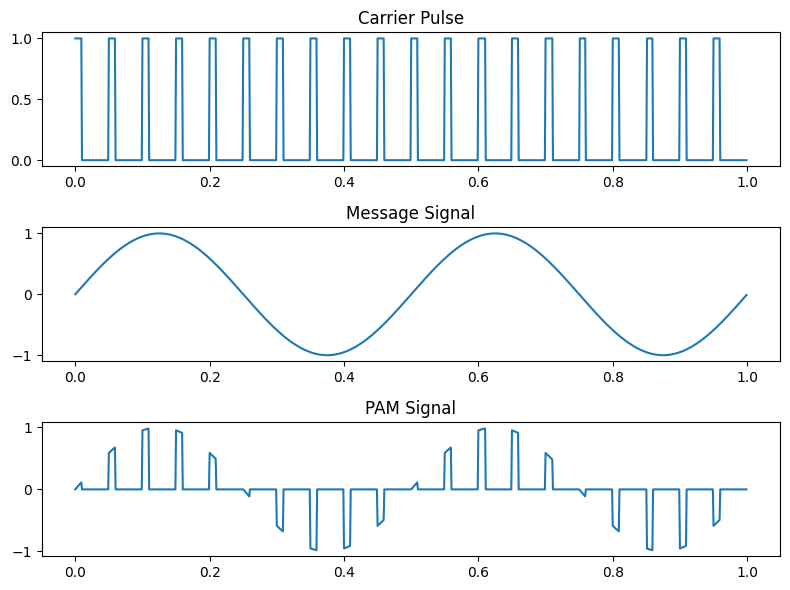

In [1]:
#lab - 1

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import square

# Parameters
fc, fm, fs = 20, 2, 1000
t, duty = 1, 0.2   # duty as fraction

# Time axis
n = np.arange(0, t, 1/fs)

# Carrier pulse (0 or 1)
carrier = (square(2*np.pi*fc*n, duty=duty) + 1) / 2

# Message signal
message = np.sin(2*np.pi*fm*n)

# PAM signal (direct multiplication)
pam = message * carrier

# Plotting
plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.plot(n, carrier)
plt.title("Carrier Pulse")

plt.subplot(3,1,2)
plt.plot(n, message)
plt.title("Message Signal")

plt.subplot(3,1,3)
plt.plot(n, pam)
plt.title("PAM Signal")

plt.tight_layout()
plt.show()

C:\Users\Arifur Rahman\AppData\Local\Temp\ipykernel_192\1610033655.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(chunks * carrier, axis=1)


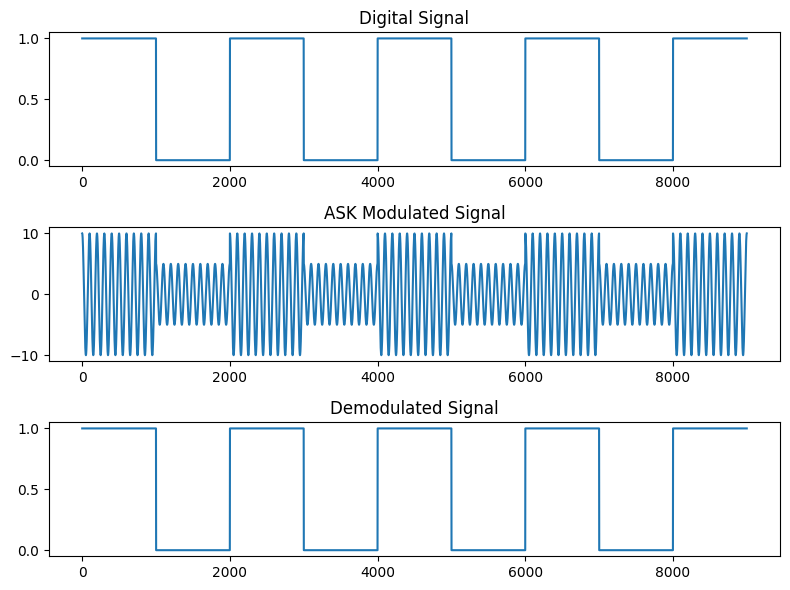

Transmitted: [1 0 1 0 1 0 1 0 1]
Received   : [1 0 1 0 1 0 1 0 1]


In [3]:
#lab - 2

import numpy as np
import matplotlib.pyplot as plt

# Binary data
bits = np.array([1,0,1,0,1,0,1,0,1])

# Parameters
bp = 1e-6                 # bit period
fs = 1000                 # samples per bit
t = np.linspace(0, bp, fs)
f = 10 / bp               # carrier frequency
A1, A2 = 10, 5            # amplitudes

# Digital signal
digital = np.repeat(bits, fs)

# ASK modulation
carrier = np.cos(2*np.pi*f*t)
ask = np.concatenate([
    (A1 if b==1 else A2) * carrier for b in bits
])

# Demodulation (simple energy detection)
chunks = ask.reshape(len(bits), fs)
energy = np.trapz(chunks * carrier, axis=1)
received = (energy > np.mean(energy)).astype(int)

# Plot
plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.plot(digital)
plt.title("Digital Signal")

plt.subplot(3,1,2)
plt.plot(ask)
plt.title("ASK Modulated Signal")

plt.subplot(3,1,3)
plt.plot(np.repeat(received, fs))
plt.title("Demodulated Signal")

plt.tight_layout()
plt.show()

print("Transmitted:", bits)
print("Received   :", received)

C:\Users\Arifur Rahman\AppData\Local\Temp\ipykernel_192\1259451468.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  corr = np.trapz(chunks * carrier, axis=1)


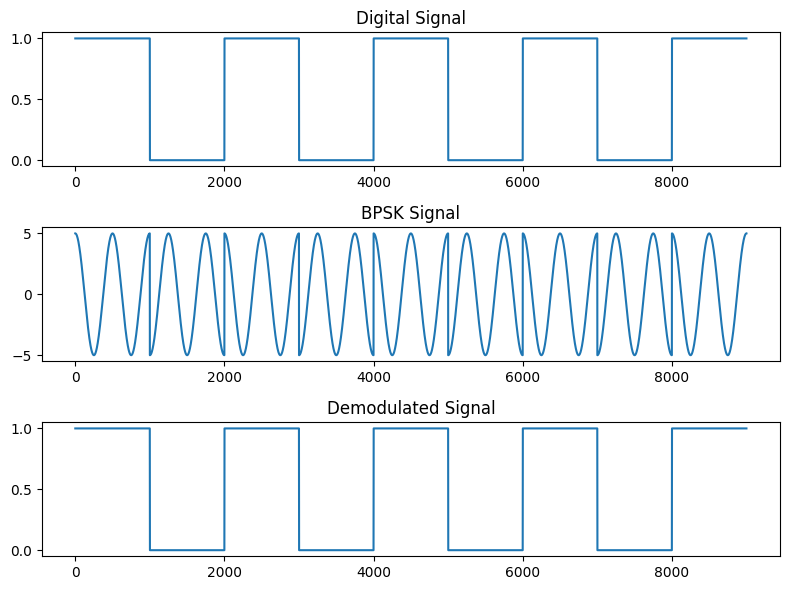

Transmitted: [1 0 1 0 1 0 1 0 1]
Received   : [1 0 1 0 1 0 1 0 1]


In [4]:
#lab - 3

import numpy as np
import matplotlib.pyplot as plt

# Binary data
bits = np.array([1,0,1,0,1,0,1,0,1])

# Parameters
bp = 1e-6
fs = 1000
t = np.linspace(0, bp, fs)
f = 2 / bp
A = 5

# Digital signal
digital = np.repeat(bits, fs)

# Carrier
carrier = np.cos(2*np.pi*f*t)

# BPSK modulation (phase shift)
psk = np.concatenate([
    A * carrier if b==1 else -A * carrier for b in bits
])

# Demodulation (correlation)
chunks = psk.reshape(len(bits), fs)
corr = np.trapz(chunks * carrier, axis=1)
received = (corr > 0).astype(int)

# Plot
plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.plot(digital)
plt.title("Digital Signal")

plt.subplot(3,1,2)
plt.plot(psk)
plt.title("BPSK Signal")

plt.subplot(3,1,3)
plt.plot(np.repeat(received, fs))
plt.title("Demodulated Signal")

plt.tight_layout()
plt.show()

print("Transmitted:", bits)
print("Received   :", received)

C:\Users\Arifur Rahman\AppData\Local\Temp\ipykernel_192\3672795136.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  c1 = np.trapz(chunks * np.cos(2*np.pi*f1*t), axis=1)
C:\Users\Arifur Rahman\AppData\Local\Temp\ipykernel_192\3672795136.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  c2 = np.trapz(chunks * np.cos(2*np.pi*f2*t), axis=1)


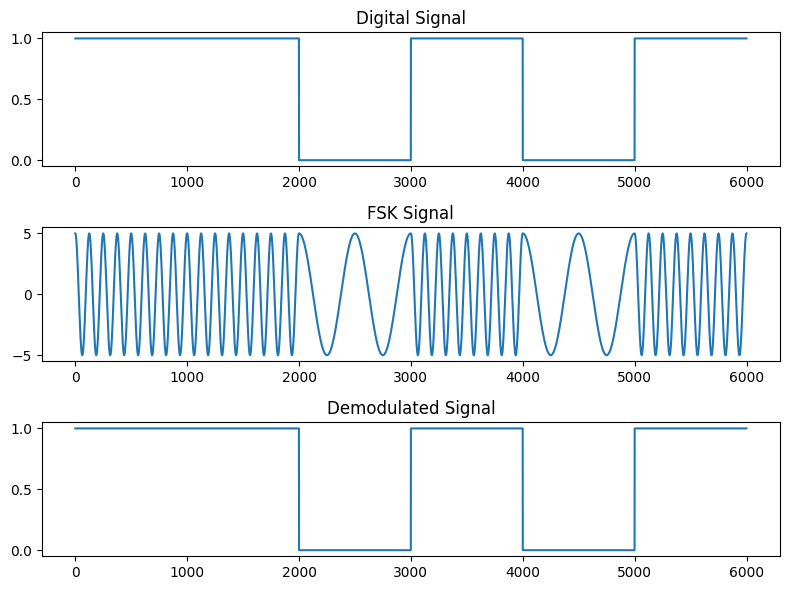

Transmitted: [1 1 0 1 0 1]
Received   : [1 1 0 1 0 1]


In [5]:
#lab - 4

import numpy as np
import matplotlib.pyplot as plt

# Binary data
bits = np.array([1,1,0,1,0,1])

# Parameters
bp = 1e-6
fs = 1000
t = np.linspace(0, bp, fs)

A = 5
f1 = 8 / bp   # frequency for bit 1
f2 = 2 / bp   # frequency for bit 0

# Digital signal
digital = np.repeat(bits, fs)

# FSK modulation
fsk = np.concatenate([
    A*np.cos(2*np.pi*(f1 if b==1 else f2)*t) for b in bits
])

# Demodulation (correlation with both frequencies)
chunks = fsk.reshape(len(bits), fs)

c1 = np.trapz(chunks * np.cos(2*np.pi*f1*t), axis=1)
c2 = np.trapz(chunks * np.cos(2*np.pi*f2*t), axis=1)

received = (c1 > c2).astype(int)

# Plot
plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.plot(digital)
plt.title("Digital Signal")

plt.subplot(3,1,2)
plt.plot(fsk)
plt.title("FSK Signal")

plt.subplot(3,1,3)
plt.plot(np.repeat(received, fs))
plt.title("Demodulated Signal")

plt.tight_layout()
plt.show()

print("Transmitted:", bits)
print("Received   :", received)

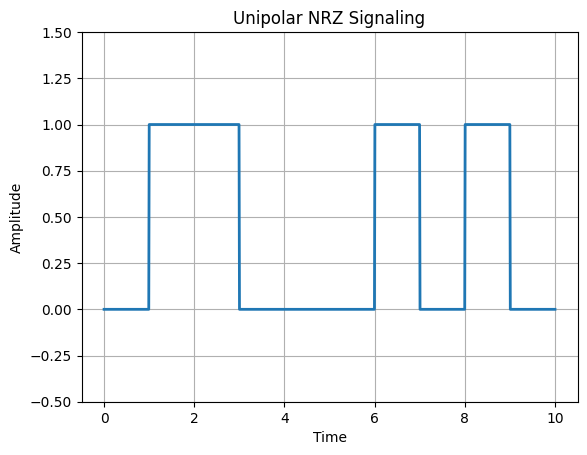

Bits: [0 1 1 0 0 0 1 0 1 0]


In [11]:
#lab - 5

import numpy as np
import matplotlib.pyplot as plt

# Number of bits
N = 10

# Random bits (0 or 1)
#bits = np.random.randint(0, 2, N)
bits = np.array([0,1,1,0,0,0,1,0,1,0])

# Samples per bit
fs = 100

# Unipolar NRZ signal (just repeat bits)
signal = np.repeat(bits, fs)

# Time axis
t = np.linspace(0, N, len(signal))

# Plot
plt.plot(t, signal, linewidth=2)
plt.ylim(-0.5, 1.5)
plt.title("Unipolar NRZ Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

print("Bits:", bits)

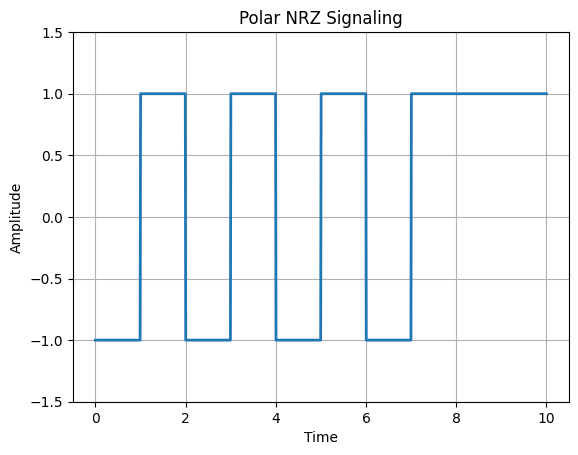

Bits : [0 1 0 1 0 1 0 1 1 1]
Mapped: [-1  1 -1  1 -1  1 -1  1  1  1]


In [10]:
#lab - 6

import numpy as np
import matplotlib.pyplot as plt

# Number of bits
N = 10

# Random bits
#bits = np.random.randint(0, 2, N)
bits = np.array([0,1,0,1,0,1,0,1,1,1])

# Map: 0 → -1, 1 → +1
polar = 2*bits - 1

# Samples per bit
fs = 100

# Signal (repeat each bit)
signal = np.repeat(polar, fs)

# Time axis
t = np.linspace(0, N, len(signal))

# Plot
plt.plot(t, signal, linewidth=2)
plt.ylim(-1.5, 1.5)
plt.title("Polar NRZ Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

print("Bits :", bits)
print("Mapped:", polar)

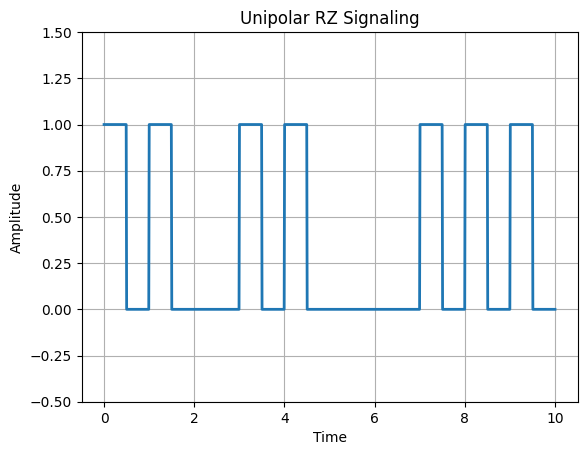

Bits: [1 1 0 1 1 0 0 1 1 1]


In [13]:
#lab - 7

import numpy as np
import matplotlib.pyplot as plt

# Number of bits
N = 10

# Random bits
#bits = np.random.randint(0, 2, N)
bits = np.array([1,1,0,1,1,0,0,1,1,1])

# Samples per bit
fs = 100

# Half-bit samples
half = fs // 2

# RZ signal (1 → [1,0], 0 → [0,0])
rz = np.concatenate([
    np.concatenate([np.ones(half), np.zeros(half)]) if b==1
    else np.zeros(fs)
    for b in bits
])

# Time axis
t = np.linspace(0, N, len(rz))

# Plot
plt.plot(t, rz, linewidth=2)
plt.ylim(-0.5, 1.5)
plt.title("Unipolar RZ Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

print("Bits:", bits)

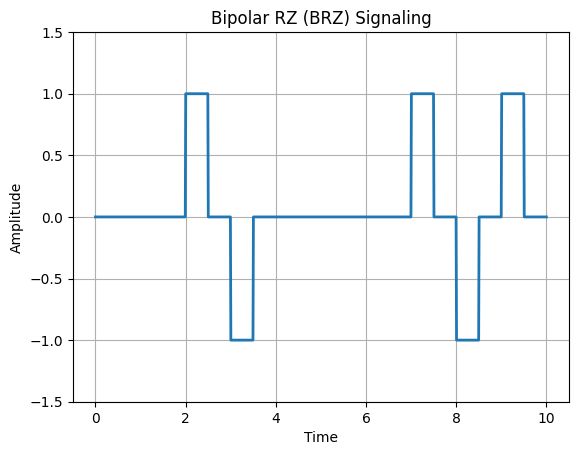

Bits    : [0 0 1 1 0 0 0 1 1 1]
Bipolar : [ 0  0  1 -1  0  0  0  1 -1  1]


In [17]:
#lab - 8

import numpy as np
import matplotlib.pyplot as plt

# Number of bits
N = 10

# Random bits
#bits = np.random.randint(0, 2, N)
bits = np.array([0,0,1,1,0,0,0,1,1,1])

# Convert to bipolar (AMI)
bipolar = []
last = 1
for b in bits:
    if b == 1:
        bipolar.append(last)
        last *= -1   # alternate sign
    else:
        bipolar.append(0)

bipolar = np.array(bipolar)

# Samples per bit
fs = 100
half = fs // 2

# RZ shaping
signal = np.concatenate([
    np.concatenate([np.full(half, b), np.zeros(half)])
    for b in bipolar
])

# Time axis
t = np.linspace(0, N, len(signal))

# Plot
plt.plot(t, signal, linewidth=2)
plt.ylim(-1.5, 1.5)
plt.title("Bipolar RZ (BRZ) Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

print("Bits    :", bits)
print("Bipolar :", bipolar)

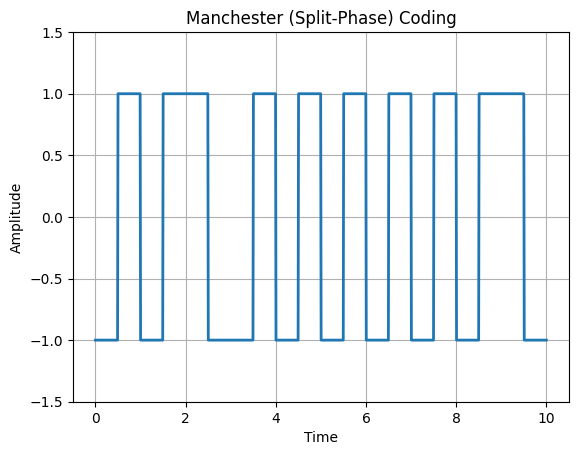

Bits      : [0 0 1 0 0 0 0 0 0 1]
Manchester: [-1  1 -1  1  1 -1 -1  1 -1  1 -1  1 -1  1 -1  1 -1  1  1 -1]


In [19]:
#lab - 9

import numpy as np
import matplotlib.pyplot as plt

# Number of bits
N = 10

# Random bits
#bits = np.random.randint(0, 2, N)
bits = np.array([0,0,1,0,0,0,0,0,0,1])

# Manchester mapping: 1 → [1,-1], 0 → [-1,1]
manchester = np.concatenate([
    [1, -1] if b==1 else [-1, 1] for b in bits
])

# Samples per half-bit
fs = 50

# Signal: repeat each half-bit
signal = np.repeat(manchester, fs)

# Time axis
t = np.linspace(0, N, len(signal))

# Plot
plt.plot(t, signal, linewidth=2)
plt.ylim(-1.5, 1.5)
plt.title("Manchester (Split-Phase) Coding")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

print("Bits      :", bits)
print("Manchester:", manchester)

Original bits: [0 1 1 0 0 0 1 1]


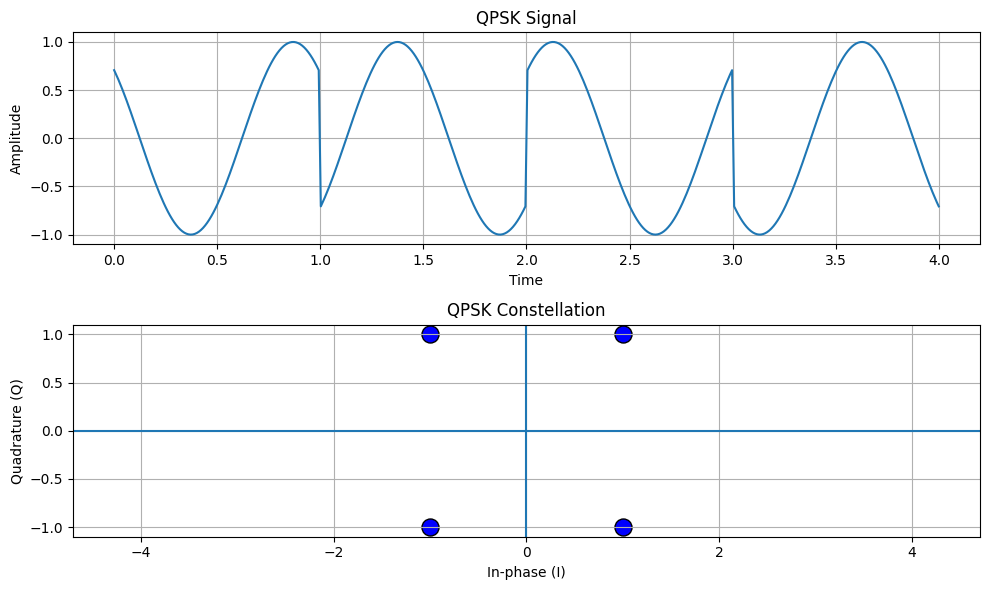

Demodulated bits: [0 1 1 0 0 0 1 1]
Error: 0


In [32]:
#lab - 10

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Input bits (must be even)
bits = np.array([0,1,1,0,0,0,1,1])
print("Original bits:", bits)

# Step 2: Correct QPSK Gray coding mapping
# Standard Gray coding for QPSK: adjacent symbols differ by 1 bit
mapping = {
    (0,0): ( 1,  1),  # 00 → 45°
    (0,1): ( 1, -1),  # 01 → 315° 
    (1,1): (-1, -1),  # 11 → 225°
    (1,0): (-1,  1)   # 10 → 135°
}

# Step 3: Group bits into symbols
symbols = bits.reshape(-1, 2)
I, Q = zip(*[mapping[tuple(b)] for b in symbols])
I = np.array(I)
Q = np.array(Q)

# Step 4: Generate QPSK waveform (normalized)
samples_per_symbol = 100
t_symbol = np.linspace(0, 1, samples_per_symbol)
signal = []

for i in range(len(I)):
    s = (I[i]*np.cos(2*np.pi*t_symbol) + Q[i]*np.sin(2*np.pi*t_symbol)) / np.sqrt(2)
    signal.extend(s)

signal = np.array(signal)
t_total = np.linspace(0, len(I), len(signal))

# Step 5: Plot QPSK Signal
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(t_total, signal)
plt.title("QPSK Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Step 6: Plot Constellation
plt.subplot(2,1,2)
plt.scatter(I, Q, s=150, c='blue', marker='o', edgecolors='black')
plt.axhline(0)
plt.axvline(0)
plt.axis('equal')
plt.title("QPSK Constellation")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid()

plt.tight_layout()
plt.show()

# Step 7: Demodulation
demod_bits = []
for i_val, q_val in zip(I, Q):
    i_bit = 0 if i_val > 0 else 1
    q_bit = 0 if q_val > 0 else 1
    demod_bits.extend([i_bit, q_bit])

demod_bits = np.array(demod_bits)

# Output
print("Demodulated bits:", demod_bits)
print("Error:", np.sum(bits != demod_bits))

Original bits: [0 1 1 0 1 0 0 1 0 0 1 1 1 1 0 0]
Symbols (4 bits each):
 [[0 1 1 0]
 [1 0 0 1]
 [0 0 1 1]
 [1 1 0 0]]
I channel: [-1  3 -3  1]
Q channel: [ 3 -1  1 -3]


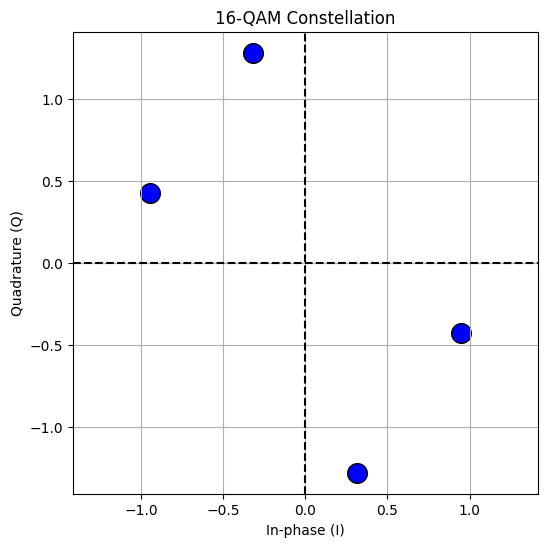

In [33]:
#lab - 11

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Input bits (must be multiple of 4 for 16-QAM)
bits = np.array([0,1,1,0,  1,0,0,1,  0,0,1,1,  1,1,0,0])  # Example 16 bits → 4 symbols
print("Original bits:", bits)

# Step 2: Group bits into 4-bit symbols
symbols = bits.reshape(-1, 4)
print("Symbols (4 bits each):\n", symbols)

# Step 3: 16-QAM mapping (Gray-coded)
# Map each 2-bit pair to I/Q amplitude levels: -3, -1, +1, +3
def bits_to_level(b):
    """Map 2 bits to QAM level with Gray coding"""
    mapping = {
        (0,0): -3,
        (0,1): -1,
        (1,1): 1,
        (1,0): 3
    }
    return mapping[tuple(b)]

I = np.array([bits_to_level(s[:2]) for s in symbols])
Q = np.array([bits_to_level(s[2:]) for s in symbols])
print("I channel:", I)
print("Q channel:", Q)

# Step 4: Normalize power (optional, average symbol energy = 1)
I = I / np.sqrt((np.mean(I**2 + Q**2)))
Q = Q / np.sqrt((np.mean(I**2 + Q**2)))

# Step 5: Plot the 16-QAM Constellation
plt.figure(figsize=(6,6))
plt.scatter(I, Q, s=200, c='blue', marker='o', edgecolors='black')
plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')
plt.title("16-QAM Constellation")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')
plt.show()

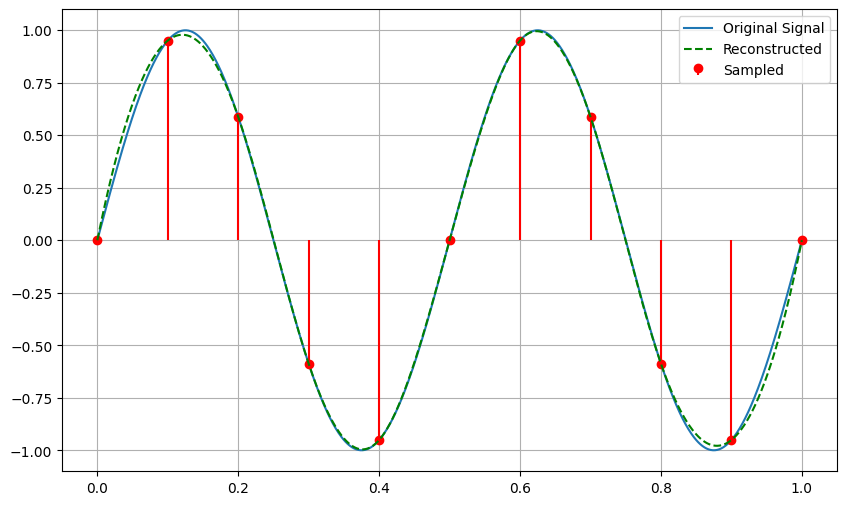

In [35]:
#lab - 12

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Continuous signal
f = 2
t = np.linspace(0, 1, 1000)
x = np.sin(2 * np.pi * f * t)

# Sampling
fs = 10
ts = np.linspace(0, 1, fs+1)   # FIXED
xs = np.sin(2 * np.pi * f * ts)

# Reconstruction
interp_func = interp1d(ts, xs, kind='cubic')
xr = interp_func(t)

# Plot
plt.figure(figsize=(10,6))
plt.plot(t, x, label="Original Signal")
plt.stem(ts, xs, linefmt='r-', markerfmt='ro', basefmt=" ", label="Sampled")
plt.plot(t, xr, '--g', label="Reconstructed")
plt.legend()
plt.grid()
plt.show()

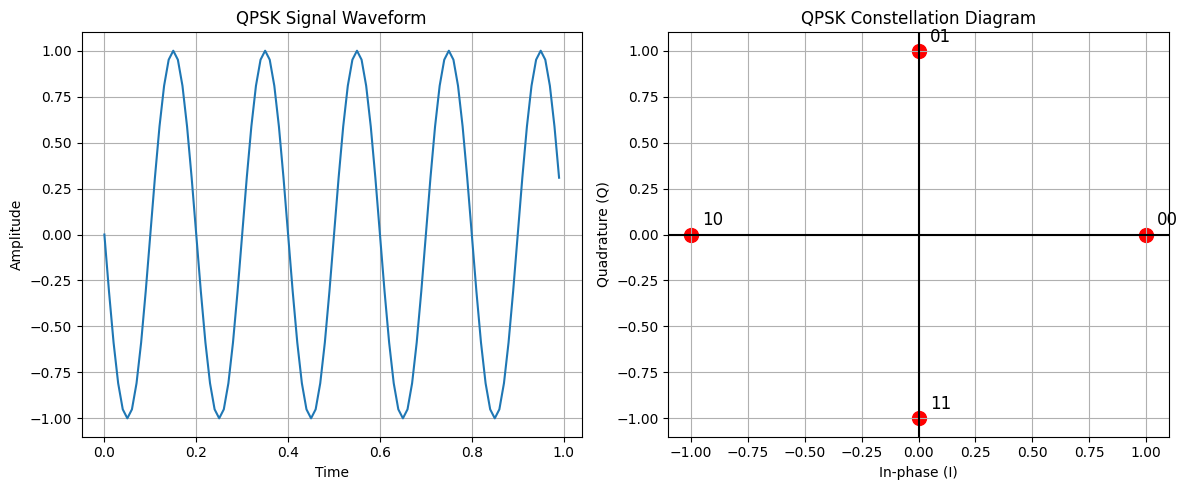

In [55]:
#lab - 13

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter 

# -------------------- Parameters --------------------
fc = 5        # carrier frequency
fs = 100      # sampling frequency
data = [0,1,1,0,1,1,0,0]  # example binary data

# -------------------- Prepare Symbols --------------------
symbols = [(data[i], data[i+1]) for i in range(0, len(data), 2)]
Ts = 0.25  # symbol duration
t_symbol = np.arange(0, Ts, 1/fs)

qpsk_signal = []

# Map symbols to phase and generate waveform
for b1, b2 in symbols:
    if (b1,b2)==(0,0): phase = 0
    elif (b1,b2)==(0,1): phase = np.pi/2
    elif (b1,b2)==(1,0): phase = np.pi
    else: phase = 3*np.pi/2
    qpsk_signal.extend(np.cos(2*np.pi*fc*t_symbol + phase))

t_total = np.arange(0, Ts*len(symbols), 1/fs)

# -------------------- Plot QPSK Signal --------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(t_total, qpsk_signal)
plt.title("QPSK Signal Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# -------------------- Constellation Diagram --------------------
phases = [0, np.pi/2, np.pi, 3*np.pi/2]
I = np.cos(phases)
Q = np.sin(phases)
labels = ['00','01','10','11']

plt.subplot(1,2,2)
plt.scatter(I, Q, color='r', s=100)
for i, label in enumerate(labels):
    plt.text(I[i]+0.05, Q[i]+0.05, label, fontsize=12)
plt.axhline(0,color='k')
plt.axvline(0,color='k')
plt.title("QPSK Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid()
plt.tight_layout()
plt.show()

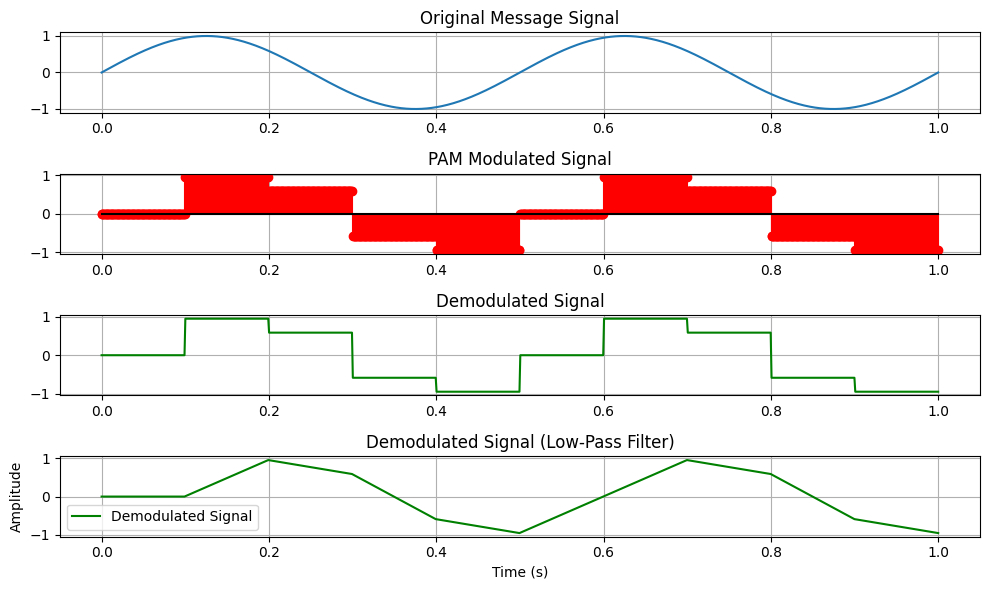

In [56]:
#lab - 14

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# ---------------- Message signal ----------------
t = np.linspace(0, 1, 1000)
msg = np.sin(2 * np.pi * 2 * t)  # 2 Hz sine wave

# ---------------- PAM Modulation ----------------
Ts = 0.1  # Pulse interval
sample_times = np.arange(0, 1, Ts)
sample_values = np.sin(2 * np.pi * 2 * sample_times)

# Create PAM signal using zero-order hold (repeat each sample)
pam_signal = np.repeat(sample_values, int(len(t)/len(sample_values)))
pam_signal = pam_signal[:len(t)]  # match lengths

# ---------------- PAM Demodulation ----------------
# Simple zero-order hold reconstruction
demod_signal = pam_signal.copy()

# ---------------- PAM Demodulation ----------------
# Simple low-pass filter to reconstruct the signal
samples_per_pulse = int(len(t)/len(sample_values))
b = np.ones(samples_per_pulse)/samples_per_pulse
demod_signal2 = lfilter(b, 1, pam_signal)

# ---------------- Plot ----------------
plt.figure(figsize=(10,6))

plt.subplot(4,1,1)
plt.plot(t, msg, label="Original Signal")
plt.title("Original Message Signal")
plt.grid()

plt.subplot(4,1,2)
plt.stem(t, pam_signal, linefmt='r', markerfmt='ro', basefmt='k-')
plt.title("PAM Modulated Signal")
plt.grid()

plt.subplot(4,1,3)
plt.plot(t, demod_signal, 'g', label="Demodulated Signal")
plt.title("Demodulated Signal")
plt.grid()

plt.subplot(4,1,4)
plt.plot(t, demod_signal2, 'g', label="Demodulated Signal")
plt.title("Demodulated Signal (Low-Pass Filter)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

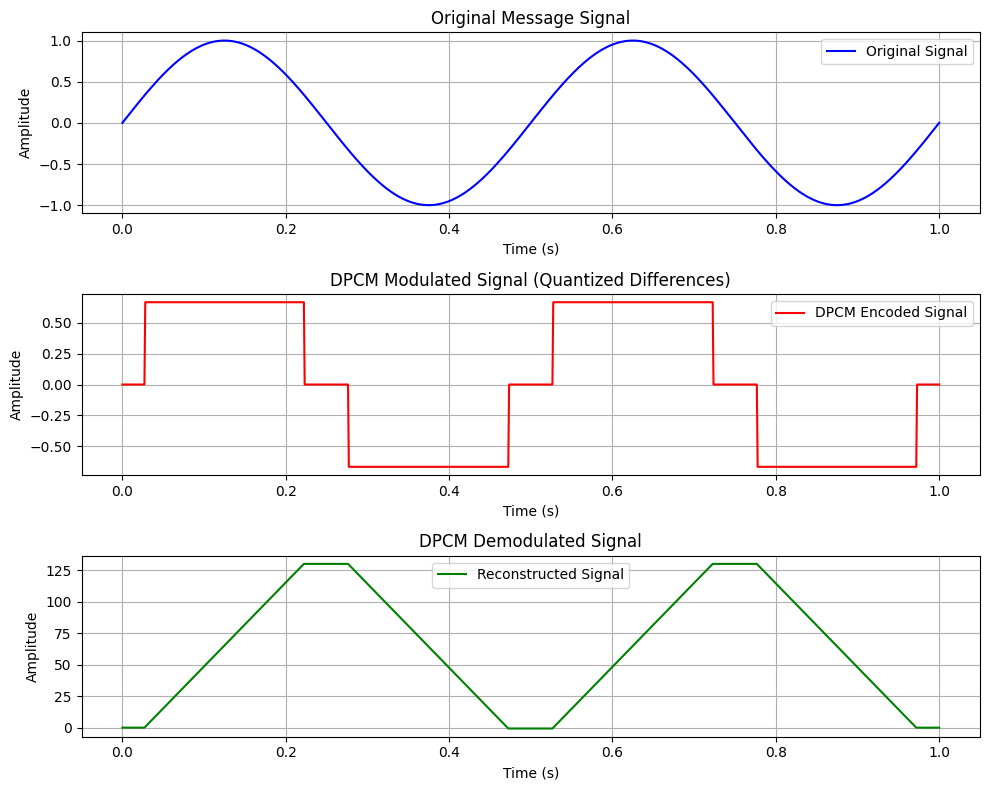

In [57]:
#lab - 15

import numpy as np
import matplotlib.pyplot as plt

# ---------------- Message Signal ----------------
fs = 1000                  # Sampling frequency
t = np.linspace(0, 1, fs)  # 1-second duration
fm = 2                      # Message frequency
message = np.sin(2 * np.pi * fm * t)  # Original analog signal

# ---------------- DPCM Modulation ----------------
# Step 1: Quantize differences
# Using simple uniform quantization (4-level DPCM)
quant_levels = 4
step_size = 2 / (quant_levels - 1)  # message amplitude assumed in [-1, 1]

# Initialize
predicted = np.zeros_like(message)
error_signal = np.zeros_like(message)
dpcm_signal = np.zeros_like(message)

# DPCM encoding
for i in range(len(message)):
    if i == 0:
        predicted[i] = 0  # initial predicted value
    error_signal[i] = message[i] - predicted[i]  # prediction error
    # Quantize the error
    quant_error = np.round(error_signal[i]/step_size) * step_size
    dpcm_signal[i] = quant_error
    predicted[i] = predicted[i] + quant_error  # update predicted value

# ---------------- DPCM Demodulation ----------------
reconstructed = np.zeros_like(message)
for i in range(len(dpcm_signal)):
    if i == 0:
        reconstructed[i] = dpcm_signal[i]
    else:
        reconstructed[i] = reconstructed[i-1] + dpcm_signal[i]

# ---------------- Plot ----------------
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t, message, 'b', label='Original Signal')
plt.title("Original Message Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()

plt.subplot(3,1,2)
plt.plot(t, dpcm_signal, 'r', label='DPCM Encoded Signal')
plt.title("DPCM Modulated Signal (Quantized Differences)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()

plt.subplot(3,1,3)
plt.plot(t, reconstructed, 'g', label='Reconstructed Signal')
plt.title("DPCM Demodulated Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()